In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:

np.random.seed(42)

# Number of students
n = 200

# Create dataset
data = {
    'study_hours': np.random.randint(1, 10, n),
    'attendance': np.random.randint(50, 100, n),
    'sleep_hours': np.random.randint(4, 10, n),
    'previous_score': np.random.randint(40, 100, n),
}

df = pd.DataFrame(data)

# Create target variable (exam score)
df['exam_score'] = (
    df['study_hours'] * 3 +
    df['attendance'] * 0.3 +
    df['sleep_hours'] * 1.5 +
    df['previous_score'] * 0.4 +
    np.random.randint(-5, 5, n)
).clip(0, 100).round(2)

print("Dataset created successfully!")
print("Shape:", df.shape)
df.head()

Dataset created successfully!
Shape: (200, 5)


,study_hours,attendance,sleep_hours,previous_score,exam_score
0,7,50,4,91,78.4
1,4,60,7,56,61.9
2,8,77,8,46,80.5
3,5,74,4,64,63.8
4,7,99,5,84,92.8


In [3]:
# Basic statistics
print(df.describe())

# Check missing values
print("\nMissing values:", df.isnull().sum().sum())

       study_hours  attendance  sleep_hours  previous_score  exam_score
count    200.00000  200.000000   200.000000      200.000000  200.000000
mean       5.07000   76.410000     6.410000       69.520000   75.016500
std        2.63435   13.964488     1.687048       17.909308   11.834859
min        1.00000   50.000000     4.000000       40.000000   47.300000
25%        3.00000   66.000000     5.000000       53.750000   68.525000
50%        5.00000   77.000000     6.500000       69.500000   75.200000
75%        7.00000   87.000000     8.000000       86.000000   81.950000
max        9.00000   99.000000     9.000000       99.000000  100.000000

Missing values: 0


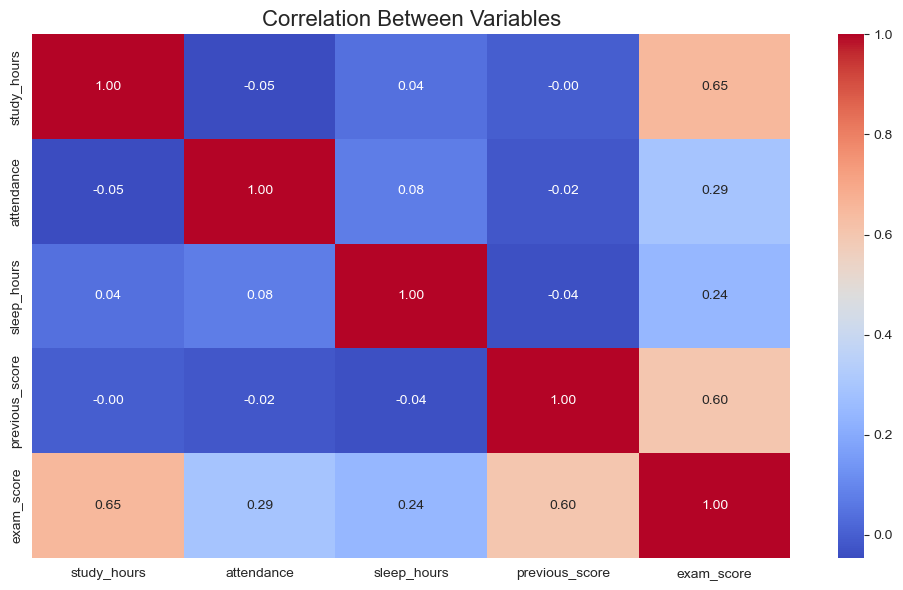

In [4]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Variables', fontsize=16)
plt.tight_layout()
plt.show()

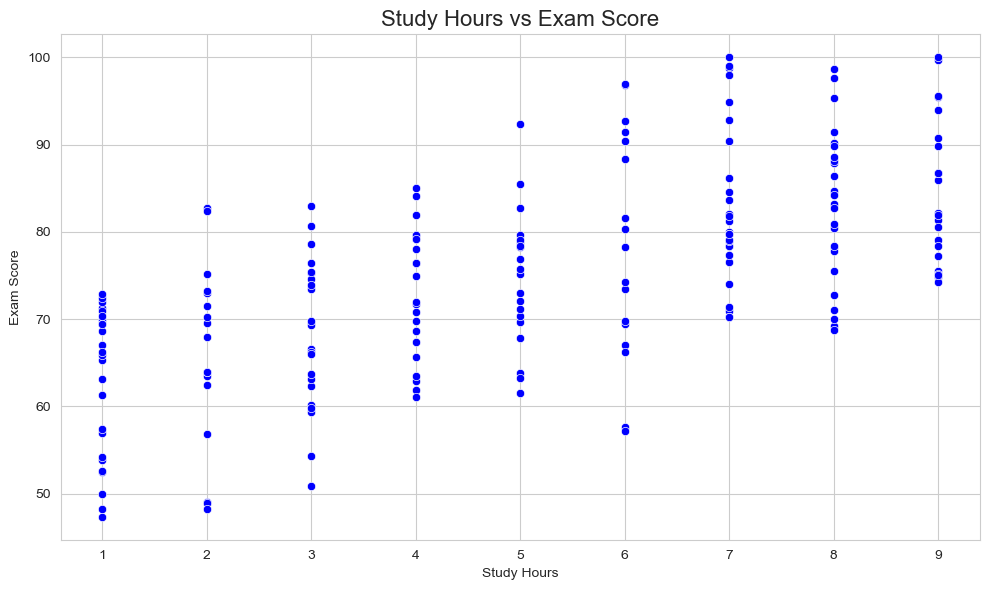

In [5]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='study_hours', y='exam_score', data=df, color='blue')
plt.title('Study Hours vs Exam Score', fontsize=16)
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.tight_layout()
plt.show()

In [6]:
# Define features and target
X = df[['study_hours', 'attendance', 'sleep_hours', 'previous_score']]
y = df['exam_score']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Model trained successfully!
Training samples: 160
Testing samples: 40


In [7]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Absolute Error: 2.51
R2 Score: 0.94


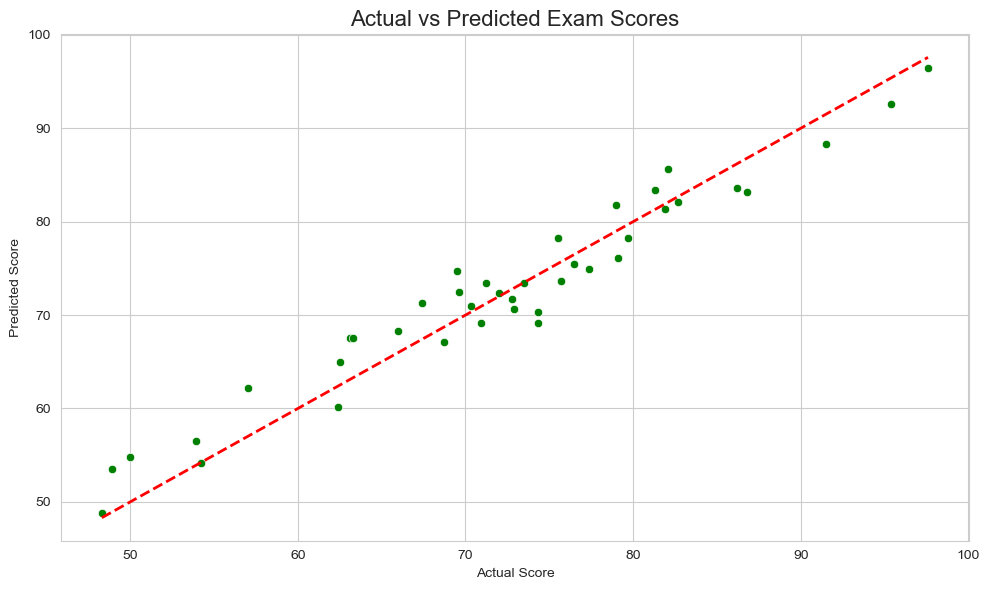

In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred, color='green')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2)
plt.title('Actual vs Predicted Exam Scores', fontsize=16)
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.tight_layout()
plt.show()

In [ ]:
# Predict score for a new student
new_student = pd.DataFrame({
    'study_hours': [7],
    'attendance': [85],
    'sleep_hours': [7],
    'previous_score': [75]
})

predicted_score = model.predict(new_student)
print(f"Predicted Exam Score: {predicted_score[0]:.2f}")